<a href="https://colab.research.google.com/github/makenzieearle/Modeling-Probability-of-the-Schrodinger-Equation/blob/main/week-3/18_quantum_error_mitigation_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install qiskit qiskit-ibm-runtime qiskit-aer
!pip install pylatexenc matplotlib
!pip install pydot
!pip install graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.9/386.9 kB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.3/111.3 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 13.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created 

##This is how we get nice things##

This is a lightly bastardized version of https://docs.quantum.ibm.com/transpile/custom-transpiler-pass

After running on a real device, you would probably found that the results were less than impressive.  In this lab, we will try and improve those results with one of the easiest error mitigation techniques, *Pauli Twirling*. Pauli twirling is an error suppression strategy that randomizes how qubits experience noisy channels.  As you have learned, two-qubit gates have much higher error rates compared to single-qubit gates.

The Pauli twirls -- in a noiseless device -- would not affect the actual two-qubit operation because they correspond to the set of single-qubit gates applied before the two-qubit gate (to the left) which are then countered by those applied after the two-qubit gate (to the right).

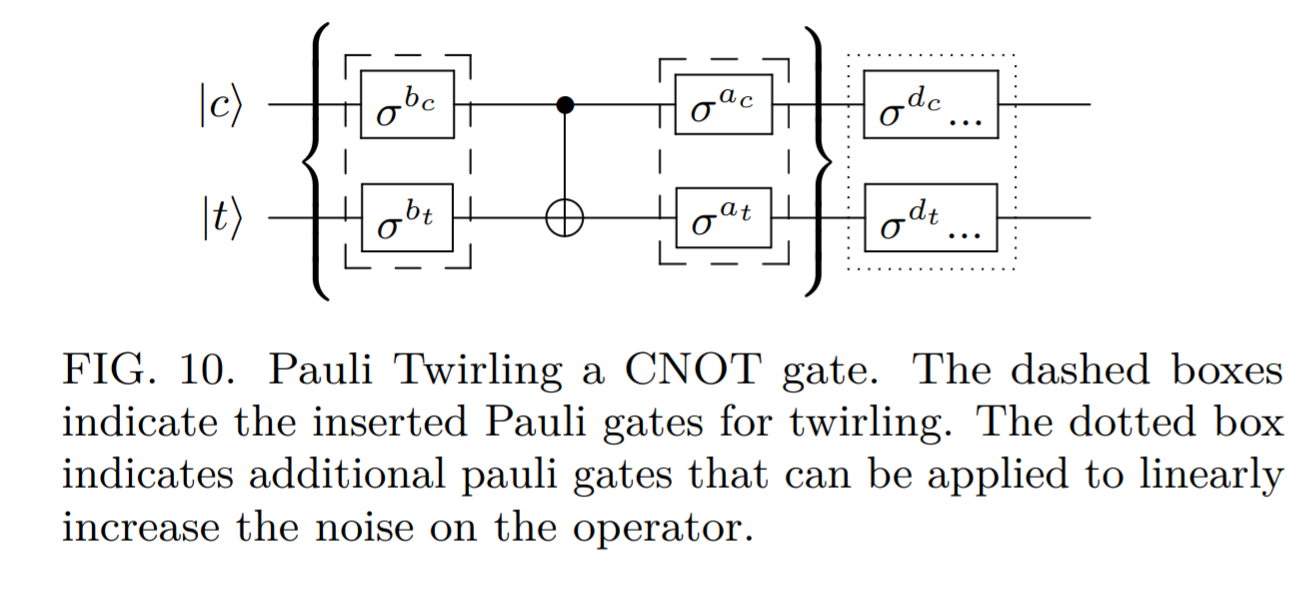

 In this sense, the two-qubit operations are identical, but the way they are performed is different. One benefit of Pauli twirling is that it turns coherent errors into stochastic errors, which can be improved by averaging more.

Before we get to the programming syntax, take a moment to work out what values of $\sigma^{b_c},\sigma^{b_t},\sigma^{a_c},\sigma^{a_t}$ could be used to twirl the CNOT gate.  These sets of 4 gates should be such that the overall operation is still that of CNOT.

(Hint: Use what you know about single qubit identites -- there should be 16)

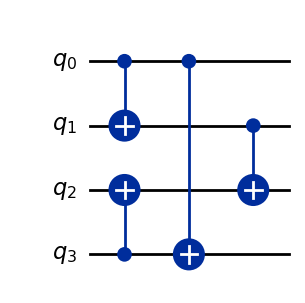

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# importing Qiskit
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit_aer import AerSimulator
from qiskit.circuit.library import MCMT, ZGate
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler

# import basic visualization tools
from qiskit.visualization import plot_histogram
from qiskit.visualization import array_to_latex
qc=QuantumCircuit(4)
bc=qc.cx(0,1)
bt=qc.cx(3,2)
ac=qc.cx(0,3)
at=qc.cx(1,2)
qc.draw("mpl")

Ok, if you are comfortable with the notion of Pauli-twirling, lets talk about how to implement it as a *custom transpiler pass*

# 18. Quantum Error Mitigation I

The Qiskit SDK allows for custom transpilation passes that go beyond the standard optimizations or that emphasize some particular algorithm for finding the 'best' gates.  This is done by running them in the `PassManager` object or addding them to a `StagedPassManager`. Here we will demonstrate how to write a  transpiler pass, focusing on building a pass that performs [Pauli twirling](https://arxiv.org/abs/quant-ph/0606161) on the noisy quantum gates in a quantum circuit.

## Transpiler passes

Transpiler passes are classified either as an [`AnalysisPass`](https://docs.quantum.ibm.com/api/qiskit/qiskit.transpiler.AnalysisPass) or a [`TransformationPass`](https://docs.quantum.ibm.com/api/qiskit/qiskit.transpiler.TransformationPass). Passes in general work with the [DAG](https://docs.quantum.ibm.com/api/qiskit/qiskit.dagcircuit.DAGCircuit) and the `property_set`, a dictionary-like object for storing properties determined by analysis passes. Analysis passes work with both the DAG and its `property_set`.  They cannot modify the DAG, but can modify the `property_set`.  This contrasts with transformation passes, which do modify the DAG, and can read (but not write to) `property_set`.  For example, transformation passes translate a circuit to its instruction set architecture (ISA) or perform routing passes to insert SWAP gates where needed.


## Create a `PauliTwirl` transpiler pass

The following example constructs a transpiler pass that adds Pauli twirls. [Pauli twirling](https://arxiv.org/abs/quant-ph/0606161) is an error suppression strategy that randomizes how qubits experience noisy channels, which we assume to be two-qubit gates in this example (because they are much more error-prone than single-qubit gates). The Pauli twirls do not affect the two-qubit gates' operation. They are chosen such that those applied *before* the two-qubit gate (to the left) are countered by those applied *after* the two-qubit gate (to the right). In this sense, the two-qubit operations are identical, but the way they are performed is different. One benefit of Pauli twirling is that it turns coherent errors into stochastic errors, which can be improved by averaging more.

Transpiler passes act on the [DAG](https://docs.quantum.ibm.com/api/qiskit/qiskit.dagcircuit.DAGCircuit), so the important method to override is `.run()`, which takes the DAG as input. Initializing pairs of Paulis as shown preserves the operation of each two-qubit gate. This is done with the helper method `build_twirl_set`, which goes through each two-qubit Pauli (as obtained from `pauli_basis(2)`) and finds the other Pauli that preserves the operation.

From the DAG, use the `op_nodes()` method to return all of its nodes. The DAG can also be used to collect runs, which are sequences of nodes that run uninterrupted on a qubit. These can be collected as single-qubit runs with `collect_1q_runs`, two-qubit runs with `collect_2q_runs`, and runs of nodes where the instruction names are in a namelist with `collect_runs`.  The `DAGCircuit` has many methods for searching and traversing a graph.  One commonly used method is `topological_op_nodes`, which provides the nodes in a dependency ordering. Other methods such as `bfs_successors` are used primarily to determine how nodes interact with subsequent operations on a DAG.

In the example, we want to replace each node, representing an instruction, with a subcircuit built as a mini DAG. The mini DAG has a two-qubit quantum register added to it.  Operations are added to the mini DAG by using `apply_operation_back`, which places the `Instruction` on the mini DAG's output (whereas `apply_operation_front` would place it on the mini DAG's input). The node is then substituted by the mini DAG by using `substitute_node_with_dag`, and the process continues over each instance of `CXGate` and `ECRGate` in the DAG (corresponding to the two-qubit basis gates on IBM® backends).


In [15]:
from qiskit.dagcircuit import DAGCircuit
from qiskit.circuit import QuantumCircuit, QuantumRegister, Gate
from qiskit.circuit.library import CXGate, ECRGate
from qiskit.transpiler import PassManager
from qiskit.transpiler.basepasses import TransformationPass
from qiskit.quantum_info import Operator, pauli_basis
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram

import numpy as np

from typing import Iterable, Optional

In [16]:
class PauliTwirl(TransformationPass):
    """Add Pauli twirls to two-qubit gates."""

    def __init__(
        self,
        gates_to_twirl: Optional[Iterable[Gate]] = None,
    ):
        """
        Args:
            gates_to_twirl: Names of gates to twirl. The default behavior is to twirl all
                two-qubit basis gates, `cx` and `ecr` for IBM backends.
        """
        if gates_to_twirl is None:
            gates_to_twirl = [CXGate(), ECRGate()]
        self.gates_to_twirl = gates_to_twirl
        self.build_twirl_set()
        super().__init__()

    def build_twirl_set(self):
        """
        Build a set of Paulis to twirl for each gate and store internally as .twirl_set.
        """
        self.twirl_set = {}
        #Instead of actually implementing a table, such as the one you derived above,
        #IBM suggests just looping through all the possible gates and adding them
        #to the list if they are equivalent.  This of course has the nice benefit of working
        #For any two-qubit gate you might pass in.
        # iterate through gates to be twirled
        for twirl_gate in self.gates_to_twirl:
            twirl_list = []

            # iterate through Paulis on left of gate to twirl
            for pauli_left in pauli_basis(2):

                # iterature through Paulis on right of gate to twirl
                for pauli_right in pauli_basis(2):

                    # save pairs that produce identical operation as gate to twirl
                    if (Operator(pauli_left) @ Operator(twirl_gate)).equiv(Operator(twirl_gate) @ pauli_right):
                        twirl_list.append((pauli_left, pauli_right))

            self.twirl_set[twirl_gate.name] = twirl_list

    def run(
        self,
        dag: DAGCircuit,
    ) -> DAGCircuit:

        # collect all nodes in DAG and proceed if it is to be twirled
        twirling_gate_classes = tuple(gate.base_class for gate in self.gates_to_twirl)
        for node in dag.op_nodes():
            if not isinstance(node.op, twirling_gate_classes):
                continue

            # random integer to select Pauli twirl pair
            pidx = np.random.randint(0, len(self.twirl_set[node.op.name]),)
            twirl_pair = self.twirl_set[node.op.name][pidx]

            # instantiate mini_dag and attach quantum register
            mini_dag = DAGCircuit()
            register = QuantumRegister(2)
            mini_dag.add_qreg(register)

            # apply left Pauli, gate to twirl, and right Pauli to empty mini-DAG
            mini_dag.apply_operation_back(twirl_pair[0].to_instruction(), [register[0], register[1]])
            mini_dag.apply_operation_back(node.op, [register[0], register[1]])
            mini_dag.apply_operation_back(twirl_pair[1].to_instruction(), [register[0], register[1]])

            # substitute gate to twirl node with twirling mini-DAG
            dag.substitute_node_with_dag(node, mini_dag)

        return dag

## Use the `PauliTwirl` transpiler pass

The following sets of code cells are going to use the pass created above to transpile a circuit.

To do so, in the next cell let's build a circuit with **3 qubits**, and then implement:

* A CNOT on $q_1$ controlled by $q_0$
  
* A *new gate* the Echoed cross-resonance gate ECR between $q_1$ and $q_2$.  Before going too far, I'd suggest you take a look at its definition https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.ECRGate

* Another ECR between $q_1$ and $q_0$
  
* A CNOT gate on $q_1$ controlled by $q_2$

When you are done, take some time to draw this circuit and make sure it matches what you expected.


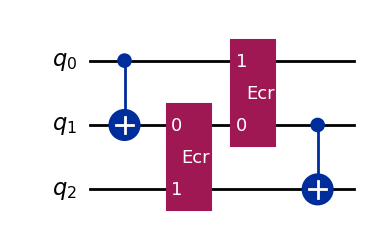

In [8]:
# your code here
q=QuantumCircuit(3)
q.cx(0,1)
q.ecr(1,2)
q.ecr(1,0)
q.cx(1,2)
q.draw("mpl")

To apply the custom pass,

* Create a new variable, `pm` and define it as a `PassManager` which takes in a list of the function `PauliTwirl()`
* Once you have done this, defined a new variable as a list of 50 runs of `pm.run()` for the circuit you defined.


In [17]:
# your code here
pm=PassManager([PauliTwirl()])

qc=[]
for i in range(50):
    qc.append(pm.run(q))

Each of these twirled circuits should now have every two-qubit gate is now sandwiched between 4 Pauli gates.

**Draw one of the circuits in the next cell to check that your intuition of the code did work.**

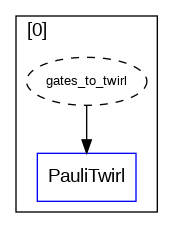

In [19]:
pm.draw("mpl")

These 50 circuits should all be the same, but there of course is a way to check.

* Try using `np.all` for a list of logical statesments where each is given by `Operator(one_circuit).equiv(second_circuit)`


In [20]:
np.all([Operator(qc[0]).equiv(qc[i]) for i in range(50)])

np.True_

If you remember back to the lecture on Quantum Algorithms, we discussed the Deutsch-Josza Algorithm, which allows while a pointless algorithm in practice, does demonstrate quantum advantage.  Here, I have provided you with the "oracle" that will produce a balanced or constant function.  

Take a minute to look at this code, and notice how it works.  Then proceed to the next cell.

In [21]:
def dj_oracle(case, n):
    # We need to make a QuantumCircuit object to return
    # This circuit has n+1 qubits: the size of the input,
    # plus one output qubit
    oracle_qc = QuantumCircuit(n+1)

    # First, let's deal with the case in which oracle is balanced
    if case == "balanced":
        # First generate a random number that tells us which CNOTs to
        # wrap in X-gates:
        b = np.random.randint(1,2**n)
        # Next, format 'b' as a binary string of length 'n', padded with zeros:
        b_str = format(b, '0'+str(n)+'b')
        # Next, we place the first X-gates. Each digit in our binary string
        # corresponds to a qubit, if the digit is 0, we do nothing, if it's 1
        # we apply an X-gate to that qubit:
        for qubit in range(len(b_str)):
            if b_str[qubit] == '1':
                oracle_qc.x(qubit)
        # Do the controlled-NOT gates for each qubit, using the output qubit
        # as the target:
        for qubit in range(n):
            oracle_qc.cx(qubit, n)
        # Next, place the final X-gates
        for qubit in range(len(b_str)):
            if b_str[qubit] == '1':
                oracle_qc.x(qubit)

    # Case in which oracle is constant
    if case == "constant":
        # First decide what the fixed output of the oracle will be
        # (either always 0 or always 1)
        output = np.random.randint(2)
        if output == 1:
            oracle_qc.x(n)

    oracle_gate = oracle_qc.to_gate()
    oracle_gate.name = "Oracle" # To show when we display the circuit
    return oracle_gate

Using a quantum computer, we can implement the Deutsch-Josza algorithm to solve the problem of balance or constant with 100% confidence after only one call to the function $f(x)$, provided we have the function $f$ implemented as a quantum oracle, which maps the state $\vert x\rangle \vert y\rangle$ to $\vert x\rangle \vert y \oplus f(x)\rangle$, where $\oplus$ is addition modulo $2$. Below is the generic circuit for the Deutsch-Jozsa algorithm.

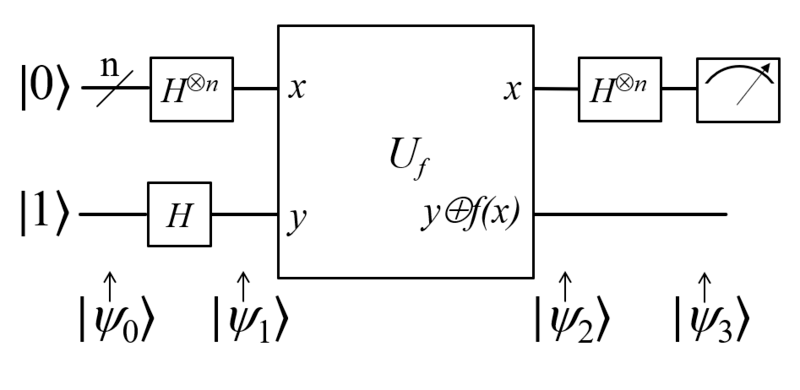

In the diagram above, $U_f$ corresponds to the gate I create in `dj_oracle`.  

Can you follow this diagram to write a function that returns a **circuit** which implements the Deutsch-Josza algorithm when you
* takes in a string `oracle` that will be passed into the `dj_oracle` function
* takes in an integer `n` which will correspond to the size of the bit-string we are checking the balance of


In [22]:

def dj_algorithm(oracle, n):
# your code here,
  q2c=QuantumCircuit(n+1)
  q2c.h(range(n))
  q2c.x(n)
  q2c.h(n)
  q2c.append(oracle,range(n+1))
  q2c.h(range(n))
  q2c.measure(range(n),range(n))
  return q2c


In this cell, lets consider the case of 4 qubits for the bit-string.

Can you:
* Construct a list of choices of oracles
* Define a variable to randomly chose an oracle
* Create a circuit `dj_circuit` that implements DJ algorithm using your previously created function

Before proceeding, try drawing your circuit.  If you re-run this cell, does the circuit change as you expect?

In [26]:
n_qubits = 4

# your code here
oracle_types = ["balanced", "constant"]
oracle_value = np.random.choice(oracle_types)
oracle_gate = dj_oracle(oracle_value, n_qubits)
dj_circuit = dj_algorithm(oracle_gate, n_qubits)

CircuitError: 'Index 0 out of range for size 0.'

In the next cell we try to connect to the real IBM devices. On a lab machine
(or Google Colab) with your IBM Quantum account set up, paste your API token into the
`token` variable below and run the cell — you should see an `<IBMBackend('ibm_...')>`
printed.

So that the rest of the notebook still runs **without** IBM credentials, the code is
guarded: if the runtime service is unavailable (no token, no network, or running on a
machine without an account), it transparently falls back to a **local `AerSimulator`**.
The real-hardware code path is kept visible so you can see exactly what would run on a
device.

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService, Batch
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_aer import AerSimulator


def get_backend():
    """Return a real IBM backend if credentials are available, else a local simulator.

    On a machine with an IBM Quantum account, paste your API token below to run on
    real hardware. Without credentials, this falls back to a local AerSimulator so the
    notebook still runs end-to-end.
    """
    try:
        # --- Real-hardware path (needs an IBM Quantum account + token) ---
        token = '??????????????????'  # paste your IBM Quantum API token here
        QiskitRuntimeService.save_account(
            channel="ibm_quantum", token=token, overwrite=True
        )
        service = QiskitRuntimeService()
        backend = service.least_busy(simulator=False)
        print(f"Using real IBM backend: {backend}")
        return backend
    except Exception as err:
        # --- Local fallback: no credentials / no network / not on a lab machine ---
        print(f"IBM runtime unavailable ({type(err).__name__}); "
              f"falling back to a local AerSimulator.")
        return AerSimulator()


backend = get_backend()
backend

The previous cell prints which backend you got.

* If you have IBM credentials and saw `<IBMBackend('ibm_[CITYNAME]')>`, **call a lab
  instructor over** before sending a real job — the real devices are heavily
  oversubscribed and a job can take hours to return.
* Otherwise you are on the local `AerSimulator`, and the cell below will run
  immediately.

The next cell twirls the Deutsch–Jozsa circuit 10 times, transpiles the batch for the
chosen `backend`, and runs them through a `SamplerV2`. When you run on real hardware it
prints a `Job ID: [SOME LETTERS AND NUMBERS]` — copy it down so you can recover your
results later if you disconnect before the job finishes.

In [ ]:
pm = PassManager([PauliTwirl()])
twirled_qcs = [pm.run(dj_circuit) for _ in range(10)]

pm = generate_preset_pass_manager(backend=backend, optimization_level=0)
transpiled_dj = pm.run(twirled_qcs)

with Batch(backend=backend):
    sampler = Sampler(backend)
    job = sampler.run(transpiled_dj)
    result = job.result()

print(f">>> Job ID: {job.job_id()}")
print(f">>> Job Status: {job.status()}")

Once you see the Job Status change to done, lets plot the results in a histogram in the next cell.

In [ ]:
temp = {}
probs = {}
counts = [{k: v / res.data.c.num_shots for k, v in res.data.c.get_counts().items()} for res in result]
for j in counts:
  for k in j:
    try:
      temp[k].append(j[k])
    except KeyError:
      temp[k] = [j[k]]

for k in temp:
  probs[k] = float(sum(temp[k])/10)

plot_histogram(probs,figsize=(17,5))

If you were ambitious and set `n_qubits` large, the histogram above may be nigh unreadable, because so many different states had a nonzero number of counts on the real device.  As a matter of analysis, lets try to combine this data is some sensible way -- *Hamming distance*.  In information theory, the Hamming distance between two strings or vectors of equal length is the number of positions at which the corresponding symbols are different.

In the noiseless case there are only two valid results $|0\rangle^n$ and $|1\rangle^n$.  Therefore, the Hamming distance from $|0\rangle^n$ -- or the number of 1s in a bitstring -- can intuitively be seen as a measure of which noiseless string $|0\rangle^n$ or $|1\rangle^n$ is more likely to be the origin of a given noisy string.  In the cell below, I have written code to collect your counts based on the Hamming distance from $|0\rangle^n$.  0 represents the $|0\rangle^n$ state, and the maximum value, $n$ represents $|1\rangle^n$ with any other value being a collection of other bitstrings.  

Is the distribution symmetric?  Or is it biased toward 0 or $n$?  Does this help in your analysis of which function you passed in?

In [ ]:
temp = {}
hamming = {}
for j in counts:
  for k in j:
    try:
      temp[k.count('1')].append(j[k])
    except KeyError:
      temp[k.count('1')] = [j[k]]

for k in temp:
  hamming[k] = float(sum(temp[k])/10)

plot_histogram(hamming)

Which type of function do you think you ran your computer with?  To check, run the next cell

In [ ]:
print(oracle_value)